In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from sklearn.cluster import MiniBatchKMeans
import matplotlib.colors as mcolors

exp_name = "5sec_gamma"
save_path = Path(r"E:\ae2d_experiments") / exp_name
save_emb_path = save_path / "embeddings"
save_meta_path = save_path / "meta_rows"

In [4]:
emb_files = sorted(list(save_emb_path.glob("embeddings_batch_*.pt")))
meta_files = sorted(list(save_meta_path.glob("meta_rows_*.csv")))
emb_mean = torch.load(save_path / "embedding_mean.pt", weights_only=True)
emb_scale = torch.load(save_path / "embedding_scale.pt", weights_only=True)

all_embeddings = torch.empty((0, emb_mean.shape[0]))
df_meta = pd.DataFrame()
for emb_file, meta_file in zip(emb_files, meta_files):
    emb_batch = torch.load(emb_file, weights_only=True)
    meta_batch = pd.read_csv(meta_file)
    all_embeddings = torch.cat((all_embeddings, emb_batch), dim=0)
    df_meta = pd.concat([df_meta, meta_batch])

embeds_std = (all_embeddings - emb_mean) / emb_scale
df_meta["d1_std"] = embeds_std[:, 0].numpy()
df_meta["d2_std"] = embeds_std[:, 1].numpy()
df_meta["d1"] = all_embeddings[:, 0].numpy()
df_meta["d2"] = all_embeddings[:, 1].numpy()

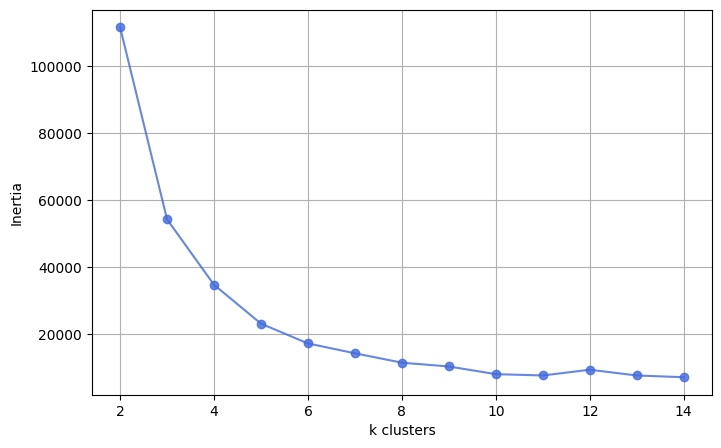

In [6]:
# Inertia experiment.
n_clusters_list = list(range(2, 15))
inertia_list = []
for n_clusters in n_clusters_list:
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=104, batch_size=256)
    kmeans.fit(embeds_std)
    inertia_list.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_clusters_list, inertia_list, marker="o", color="royalblue", alpha=0.8)
ax.set_xlabel("k clusters")
ax.set_ylabel("Inertia")
plt.grid(True)
plt.show()

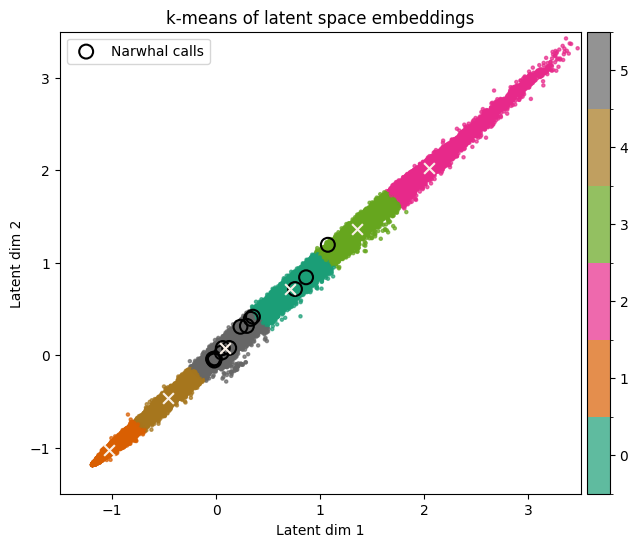

In [9]:
kmeans = MiniBatchKMeans(n_clusters=6, random_state=104, batch_size=256)
cluster_labels = kmeans.fit_predict(embeds_std.numpy())
cluster_centers = kmeans.cluster_centers_

val_segs = pd.read_csv(r"C:\Users\Lindholm\Documents\BSc\bsc_project\data_management\validated_call_segments.csv")

# Plotting validated calls.
df_meta["cluster"] = cluster_labels
mask_val = df_meta["file"].str.contains("6230.220917120000.npz") | df_meta["file"].str.contains("6230.221003000000.npz")
df_meta_val = df_meta[mask_val].copy()

mask_calls = df_meta_val.merge(
    val_segs.rename(columns={"start_frame":"start", "end_frame":"end"})[["file","start","end"]],
    on=["file","start","end"],
    how="left",
    indicator=True
)["_merge"].eq("both")

df_meta_val["is_narwhal_call"] = mask_calls.values
df_only_calls = df_meta_val[df_meta_val["is_narwhal_call"]]

cmap = plt.get_cmap("Dark2", 6)
norm = mcolors.BoundaryNorm(np.arange(-0.5, 6+0.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(embeds_std[:, 0], embeds_std[:, 1], c=cluster_labels, cmap=cmap, norm=norm, s=5, alpha=0.7)
plt.scatter(df_only_calls["d1_std"], df_only_calls["d2_std"], facecolors="none", color="black", s=100, lw=1.5, label="Narwhal calls")
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker="x", s=60, c="linen")
colorbar = plt.colorbar(scatter, ticks=np.arange(6), pad=0.01)
ax.set_xlabel("Latent dim 1")
ax.set_ylabel("Latent dim 2")
ax.set_ylim(-1.5, 3.5)
ax.set_xlim(-1.5, 3.5)
plt.title("k-means of latent space embeddings")
plt.legend()
plt.show()

In [10]:
# print(df_meta["cluster"].value_counts())
df_c5 = df_meta[df_meta["cluster"] == 5]
print(df_c5.shape)
print(df_c5["file"].nunique())
df_c5.sample(30)

(37228, 10)
1534


,file,start,end,batch,i_in_batch,d1_std,d2_std,d1,d2,cluster
344,D:\logmel_outputs_9979\Tracy_6230\6230.2208270...,31875,32500,207,344,-0.032086,-0.094183,1.629684,2.944853,5
140,D:\logmel_outputs_9979\Tracy_6230\6230.2209011...,13125,13750,74,140,0.285639,0.237108,2.074037,3.827875,5
178,D:\logmel_outputs_9979\Tracy_6230\6230.2209221...,7500,8125,246,178,0.306387,0.270073,2.103054,3.915740,5
349,D:\logmel_outputs_9979\Tracy_6230\6230.2208310...,3750,4375,333,349,0.040599,0.027181,1.731337,3.268336,5
15,D:\logmel_outputs_9979\Tracy_6230\6230.2209201...,10625,11250,120,15,0.356601,0.310248,2.173280,4.022822,5
311,D:\logmel_outputs_9979\Tracy_6230\6230.2210021...,31250,31875,412,311,-0.139452,-0.186617,1.479528,2.698479,5
62,D:\logmel_outputs_9979\Tracy_6230\6230.2209192...,20000,20625,107,62,0.232947,0.143813,2.000345,3.579207,5
498,D:\logmel_outputs_9979\Tracy_6230\6230.2209300...,9375,10000,158,498,-0.016781,0.030867,1.651089,3.278161,5
409,D:\logmel_outputs_9979\Tracy_6230\6230.2209151...,2500,3125,71,409,0.226253,0.228066,1.990983,3.803774,5
317,D:\logmel_outputs_9979\Tracy_6230\6230.2210031...,5625,6250,260,317,0.013117,0.052141,1.692902,3.334863,5
